In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc


df = pd.read_csv("data/Data4_a_Tieuduong.csv", encoding='latin-1')

# EDA

In [3]:
df.head()

,Times_Pregnant,ï¿½Glucose_Concentration,Blood_Pressure,Skin_thickness,insulin,BMI,DPF,Age,Class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Times_Pregnant            768 non-null    int64  
 1   ï¿½Glucose_Concentration  768 non-null    int64  
 2   Blood_Pressure            768 non-null    int64  
 3   Skin_thickness            768 non-null    int64  
 4   insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DPF                       768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Class                     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# Check NULL
print("Null:", df.isnull().sum().sum())
# Check duplicate
print("Duplicated:", df.duplicated().sum())

Null: 0
Duplicated: 0


# 1. Xây dựng mô hình Logistic Regression phân loại tuổi mua bảo hiểm (1 biến)

In [6]:
# Chọn X, y
X = df.drop('Class', axis=1)
y = df['Class']

# Chia tệp train, test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Classification Report:\n{class_report}")

Accuracy: 0.8246753246753247
Confusion Matrix:
[[98  9]
 [18 29]]
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       107
           1       0.76      0.62      0.68        47

    accuracy                           0.82       154
   macro avg       0.80      0.77      0.78       154
weighted avg       0.82      0.82      0.82       154



# 2. Xây dựng mô hình Logistic Regression phân loại cho vay (đa biến)

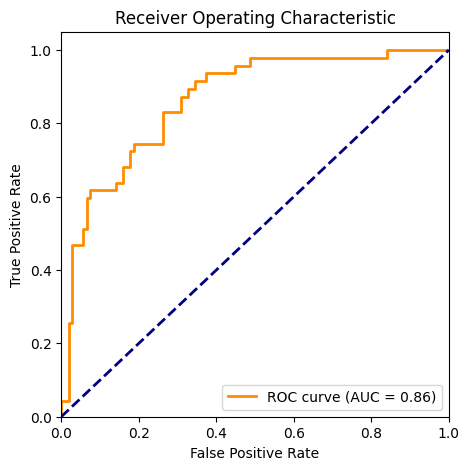

In [7]:
# Calculate the probabilities of the positive class
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate the false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate the AUC (Area Under the Curve)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()